## ASSIGNMENT 9: Stock Market Time Series

## Q9.1: Data Summary
#### Load stock data and display price statistics (open, close, high, low) per stock.

In [103]:
import pandas as pd
df=pd.read_csv('assignment9_stock_market_data(in).csv')
df

,Date,Stock,OpenPrice,HighPrice,LowPrice,ClosePrice,Volume,PE_Ratio
0,1/3/2024,Tech Mahindra,1978,1270,2005,2997,3358730,30.44
1,1/4/2024,HCL,1419,1658,1045,1412,2931375,49.10
2,1/5/2024,Wipro,1493,1962,1933,2783,5650100,35.56
3,1/6/2024,Wipro,2469,1955,578,2077,3305433,29.93
4,1/6/2024,HCL,1007,2112,2561,2679,2731530,40.89
...,...,...,...,...,...,...,...,...
247,12/21/2024,Wipro,1664,1513,501,2174,4734942,47.11
248,12/25/2024,HCL,2524,1204,2042,1169,7592863,45.73
249,12/28/2024,TCS,2914,938,963,2621,7215241,25.57
250,12/29/2024,TCS,2202,2412,1819,1706,2137317,48.13


In [104]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date']

0     2024-01-03
1     2024-01-04
2     2024-01-05
3     2024-01-06
4     2024-01-06
         ...    
247   2024-12-21
248   2024-12-25
249   2024-12-28
250   2024-12-29
251   2024-12-29
Name: Date, Length: 252, dtype: datetime64[ns]

In [105]:
stock_stats=df.groupby('Stock')[['OpenPrice','HighPrice','LowPrice','ClosePrice']].describe().reset_index()

In [106]:
print("Stock Statistics per Stock:")
stock_stats

Stock Statistics per Stock:


Stock OpenPrice                                                   \
                     count         mean         std    min      25%     50%   
0            HCL      60.0  1850.066667  754.501516  633.0  1166.25  1868.0   
1        Infosys      45.0  1682.000000  660.494133  518.0  1121.00  1806.0   
2            TCS      42.0  1655.952381  721.823435  528.0   944.50  1605.0   
3  Tech Mahindra      49.0  1853.428571  665.003665  674.0  1290.00  1919.0   
4          Wipro      56.0  1726.017857  694.082350  610.0  1060.50  1987.0   

                   HighPrice  ... LowPrice         ClosePrice               \
       75%     max     count  ...      75%     max      count         mean   
0  2555.25  2976.0      60.0  ...  2377.25  2995.0       60.0  1751.266667   
1  2157.00  2937.0      45.0  ...  2083.00  2933.0       45.0  1614.311111   
2  2272.50  2976.0      42.0  ...  2480.25  2960.0       42.0  1645.047619   
3  2507.00  2925.0      49.0  ...  2358.00  2999.0       49.0  1596.612245   
4  2314.50  2852.0      56.0  ...  2380.00  2981.0       56.0  1742.767857   

                                                       
          std    min      25%     50%     75%     max  
0  721.168564  540.0  1159.25  1694.5  2380.5  2915.0  
1  734.850227  518.0   979.00  1605.0  2259.0  2994.0  
2  701.059162  577.0  1076.00  1589.0  2228.0  2812.0  
3  670.143978  567.0  1055.00  1462.0  2035.0  2997.0  
4  748.193971  585.0  1032.50  1714.5  2440.0  2991.0  

[5 rows x 33 columns]

## Q9.2: Daily Change
#### Calculate daily price change (ClosePrice - OpenPrice) and add as new column

In [107]:
df['DailyPrice']=df['ClosePrice']-df['OpenPrice']

In [108]:
print("Daily Price Change:")
df

Daily Price Change:


,Date,Stock,OpenPrice,HighPrice,LowPrice,ClosePrice,Volume,PE_Ratio,DailyPrice
0,2024-01-03,Tech Mahindra,1978,1270,2005,2997,3358730,30.44,1019
1,2024-01-04,HCL,1419,1658,1045,1412,2931375,49.10,-7
2,2024-01-05,Wipro,1493,1962,1933,2783,5650100,35.56,1290
3,2024-01-06,Wipro,2469,1955,578,2077,3305433,29.93,-392
4,2024-01-06,HCL,1007,2112,2561,2679,2731530,40.89,1672
...,...,...,...,...,...,...,...,...,...
247,2024-12-21,Wipro,1664,1513,501,2174,4734942,47.11,510
248,2024-12-25,HCL,2524,1204,2042,1169,7592863,45.73,-1355
249,2024-12-28,TCS,2914,938,963,2621,7215241,25.57,-293
250,2024-12-29,TCS,2202,2412,1819,1706,2137317,48.13,-496


## Q9.3: Stock Metrics
#### Group by stock and calculate average volume and volatility (HighPrice - LowPrice)

In [109]:
df['Volatility']=df['HighPrice']-df['LowPrice']

In [110]:
stock=df.groupby('Stock').agg({'Volume':'mean','Volatility':'mean'}).round(2)

In [111]:
print("Stock Metrics:")
stock

Stock Metrics:


,Volume,Volatility
Stock,,
HCL,5698361.55,4.55
Infosys,5592103.93,266.71
TCS,5300644.95,-205.69
Tech Mahindra,5105094.08,-171.16
Wipro,4839924.82,154.75


## Q9.4: Single Stock Plot
#### Filter data for one stock and plot its closing price trend over time.

In [112]:
stock_name=df[df['Stock']=='Wipro'].sort_values('Date')
stock_name

,Date,Stock,OpenPrice,HighPrice,LowPrice,ClosePrice,Volume,PE_Ratio,DailyPrice,Volatility
2,2024-01-05,Wipro,1493,1962,1933,2783,5650100,35.56,1290,29
3,2024-01-06,Wipro,2469,1955,578,2077,3305433,29.93,-392,1377
8,2024-01-12,Wipro,1424,2814,1907,2297,1093246,48.19,873,907
12,2024-01-19,Wipro,759,534,690,2579,6709716,15.38,1820,-156
13,2024-01-21,Wipro,2313,1093,678,2436,5563870,46.60,123,415
17,2024-01-25,Wipro,2064,1222,2606,647,2760399,31.04,-1417,-1384
22,2024-02-07,Wipro,2726,1796,2361,1635,1926109,42.32,-1091,-565
26,2024-02-14,Wipro,919,2817,1504,1365,2545329,17.27,446,1313
27,2024-02-14,Wipro,2019,2169,1573,865,6688505,32.83,-1154,596
31,2024-02-19,Wipro,812,2383,1466,1714,5317293,45.50,902,917


In [113]:
import matplotlib.pyplot as plt

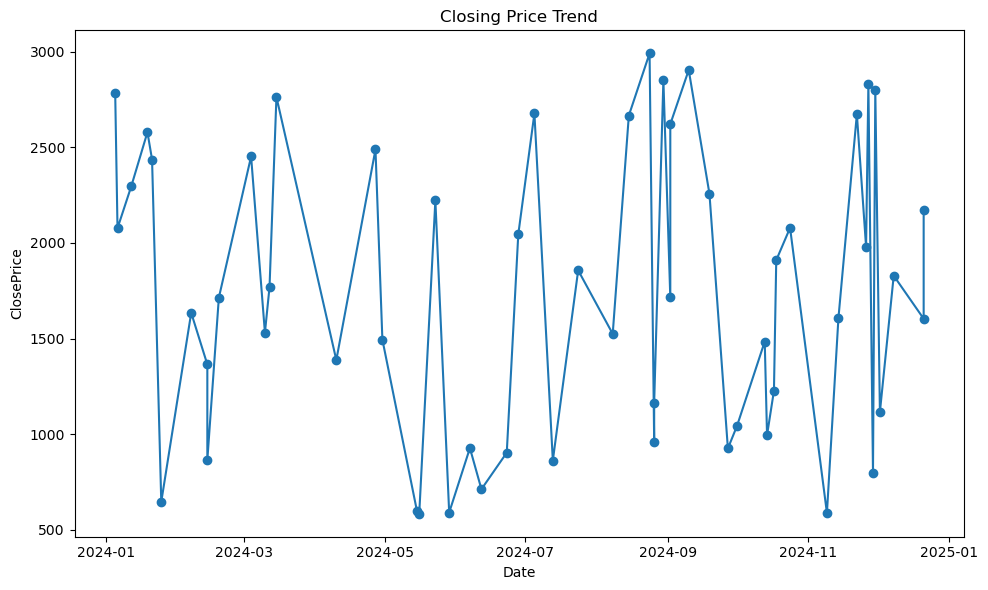

In [114]:
plt.figure(figsize=(10,6))
plt.plot(stock_name['Date'],stock_name['ClosePrice'],marker='o')
plt.title('Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('ClosePrice')
plt.tight_layout()
plt.show()

## Q9.5: Monthly Averages
#### Calculate monthly average closing price for each stock.

In [115]:
df['Month']=df['Date'].dt.month

In [116]:
monthly_avg=df.groupby('Stock')['Month'].mean().round(2)

In [117]:
print('Monthly Average per stock:')
monthly_avg.reset_index()

Monthly Average per stock:


,Stock,Month
0,HCL,6.87
1,Infosys,6.73
2,TCS,7.74
3,Tech Mahindra,5.33
4,Wipro,6.80


## Q9.6: Best & Worst Performers
#### Identify best (highest return) and worst (lowest return) performing stocks.

In [118]:
Performers=df.groupby('Stock')['DailyPrice'].mean()
best_performers=Performers.idxmax()
worst_performers=Performers.idxmin()

In [119]:
print(f"Best_Performers:{best_performers}")
print(f"Lowest_Performers:{worst_performers}")

Best_Performers:Wipro
Lowest_Performers:Tech Mahindra


## Q9.7: Pivot Table
#### Create a pivot table showing average closing price by stock and month

In [122]:
pivot=pd.pivot_table(df,index='Stock',columns='Month',values='ClosePrice',aggfunc='mean').round(2)

In [123]:
print("Pivot Table:")
pivot

Pivot Table:


Month,1,2,3,4,5,6,7,8,9,10,11,12
Stock,,,,,,,,,,,,
HCL,1677.80,1606.67,1611.86,2156.50,1491.11,1126.0,1403.0,2155.00,2239.0,1726.25,2007.40,1937.71
Infosys,882.67,1171.00,1103.00,2082.83,1412.50,1129.0,1270.5,2099.67,1858.5,1753.57,1399.50,1138.00
TCS,1185.00,1315.00,2180.00,1574.50,1449.50,1302.5,1234.0,1651.67,1615.4,1894.50,1533.67,2108.40
Tech Mahindra,2013.60,2258.67,1752.00,1831.00,1203.50,1338.0,1367.0,1092.67,1232.0,1787.00,1843.50,1424.00
Wipro,2136.50,1394.75,2128.75,1790.67,999.50,1147.5,1799.0,2026.33,2084.6,1457.00,1897.00,1680.75


## Q9.8: Multi-Stock Plot
#### Visualize closing prices for all stocks on same plot with legend

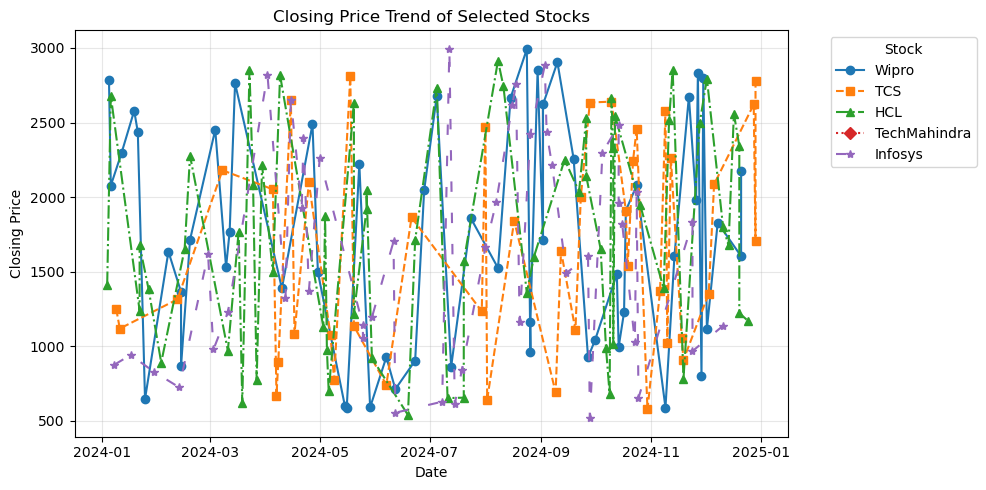

In [124]:
plt.figure(figsize=(10, 5))
stocks = ['Wipro', 'TCS', 'HCL','TechMahindra','Infosys']
linestyles = ['-', '--', '-.',':',(0,(5,10))]
markers = ['o', 's', '^','D','*']
for i, stock_name in enumerate(stocks):
    stock_data = df[df['Stock'] == stock_name].sort_values('Date')
    plt.plot(stock_data['Date'],stock_data['ClosePrice'],label=stock_name,linestyle=linestyles[i],marker=markers[i])
plt.title('Closing Price Trend of Selected Stocks')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend(title='Stock', loc='upper left', bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Q9.9: Correlation Matrix
#### Calculate correlation between stocks' closing prices using NumPy.

In [125]:
price=pd.pivot_table(df,index='Date',columns='Stock',values='ClosePrice')
correlation=price.corr()
print("Correlation Matrix:")
correlation

Correlation Matrix:


Stock,HCL,Infosys,TCS,Tech Mahindra,Wipro
Stock,,,,,
HCL,1.000000,-0.910540,0.752228,-0.933265,-0.227430
Infosys,-0.910540,1.000000,0.130624,-0.625380,0.431999
TCS,0.752228,0.130624,1.000000,1.000000,0.208313
Tech Mahindra,-0.933265,-0.625380,1.000000,1.000000,0.397146
Wipro,-0.227430,0.431999,0.208313,0.397146,1.000000


## Q9.10: Comprehensive Dashboard
#### Create a dashboard with multiple subplots showing various stock metrics.

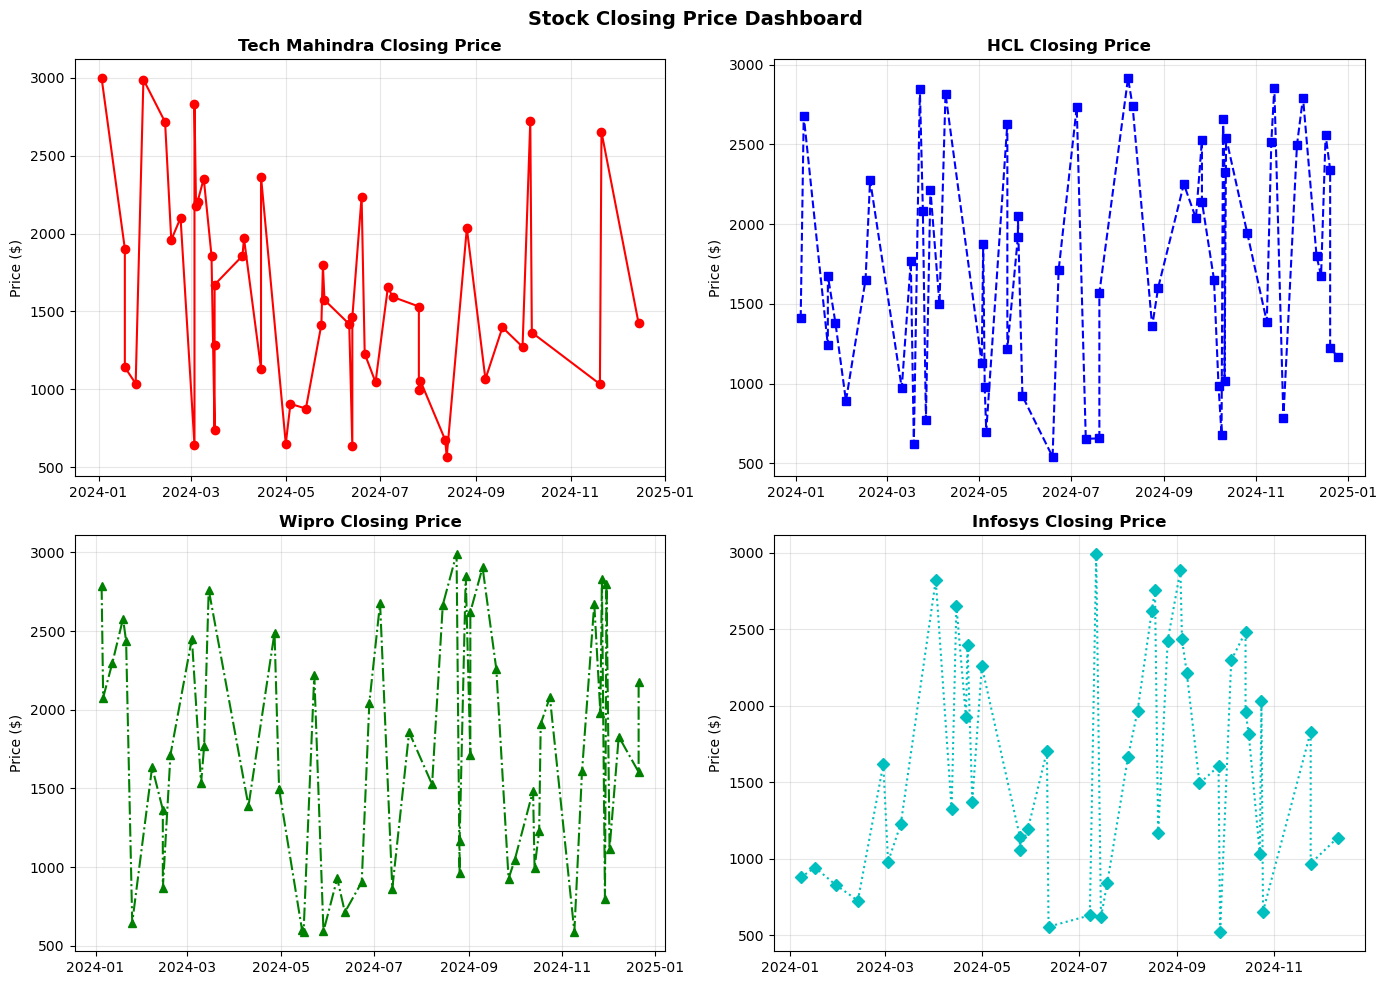

In [126]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors=['r','b','g','c']
linestyles = ['-', '--', '-.',':']
markers = ['o', 's', '^','D']
stocks = df['Stock'].unique()[:4]
for i, stock in enumerate(stocks):
    ax = axes[i//2, i%2]
    stock_data = df[df['Stock'] == stock].sort_values('Date')
    ax.plot(stock_data['Date'], stock_data['ClosePrice'],linestyle=linestyles[i],marker=markers[i], color=colors[i])
    ax.set_title(f'{stock} Closing Price', fontweight='bold')
    ax.set_ylabel('Price ($)')
    ax.grid(True, alpha=0.3)
plt.suptitle('Stock Closing Price Dashboard',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

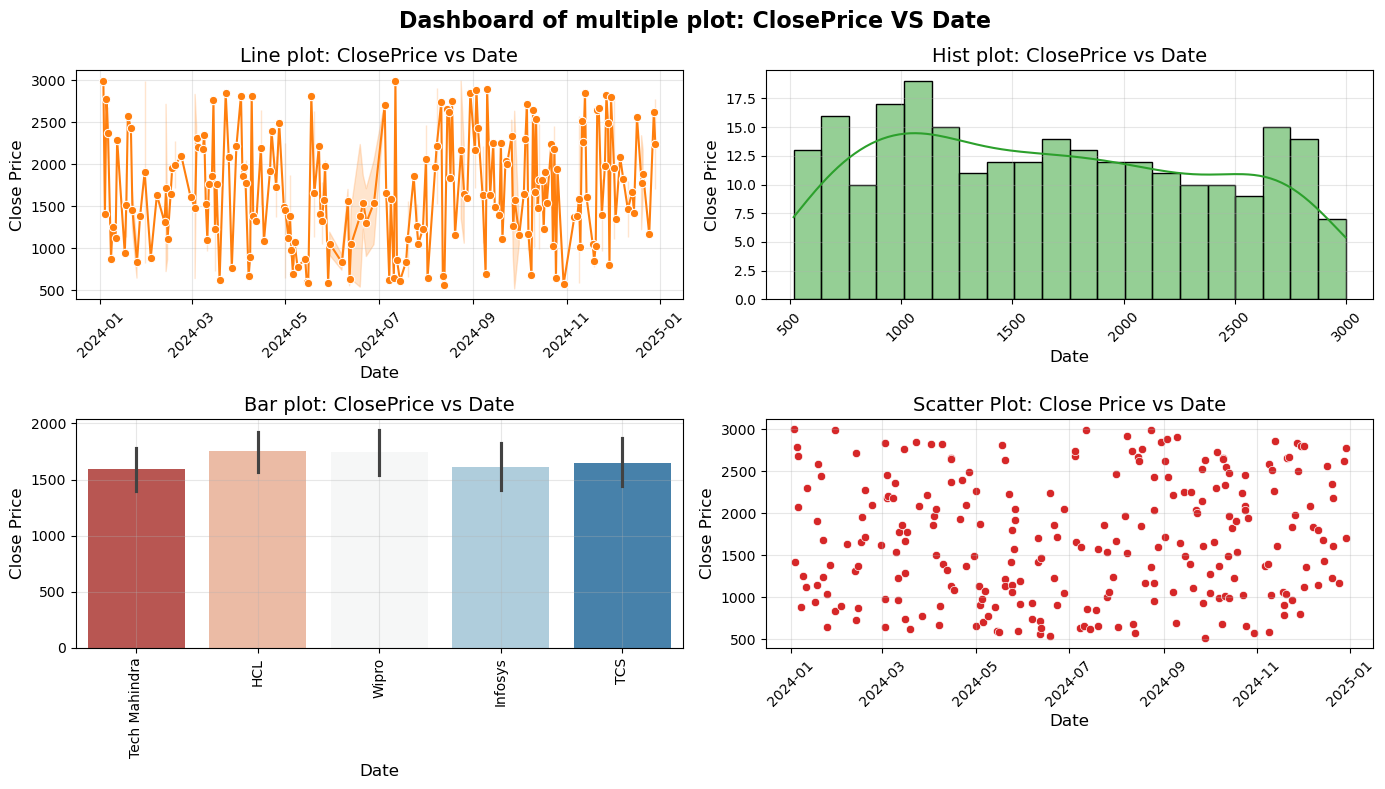

In [128]:
import seaborn as sns
fig, axs = plt.subplots(2, 2, figsize=(14,8))

sns.lineplot(data=df,x='Date',y='ClosePrice',marker='o',ax=axs[0,0],color='tab:orange')
axs[0,0].set_title('Line plot: ClosePrice vs Date',fontsize=14)
axs[0,0].set_xlabel('Date',fontsize=12)
axs[0,0].set_ylabel('Close Price',fontsize=12)
axs[0,0].grid(True, alpha=0.3)
axs[0,0].tick_params(axis='x', rotation=45)

sns.histplot(data=df,x='ClosePrice',bins=20,kde = True,ax=axs[0,1],color='tab:green')
axs[0,1].set_title('Hist plot: ClosePrice vs Date',fontsize=14)
axs[0,1].set_xlabel('Date',fontsize=12)
axs[0,1].set_ylabel('Close Price',fontsize=12)
axs[0,1].grid(True, alpha=0.3)
axs[0,1].tick_params(axis='x', rotation=45)

sns.barplot(data=df,x='Stock',y='ClosePrice',hue='Stock',ax=axs[1,0],errorbar=('ci', 95),palette='RdBu')
axs[1,0].set_title('Bar plot: ClosePrice vs Date',fontsize=14)
axs[1,0].set_xlabel('Date',fontsize=12)
axs[1,0].set_ylabel('Close Price',fontsize=12)
axs[1,0].grid(True, alpha=0.3)
axs[1,0].tick_params(axis='x', rotation=90)


sns.scatterplot(data=df,x='Date',y='ClosePrice',ax=axs[1,1],color='tab:red')
axs[1,1].set_title('Scatter Plot: Close Price vs Date',fontsize=14)
axs[1,1].set_xlabel('Date',fontsize=12)
axs[1,1].set_ylabel('Close Price',fontsize=12)
axs[1,1].grid(True, alpha=0.3)
axs[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Dashboard of multiple plot: ClosePrice VS Date',fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()